In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import GRU, Dense, Dropout
import xgboost as xgb
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

Libraries loaded
GPU available: True


In [ ]:
# Load the Merged Dataset
df = pd.read_csv('/content/final_dataset_2022_2024.csv', index_col=0)
df.index = pd.to_datetime(df.index, dayfirst=True)
df = df.sort_index()

print("Dataset loaded")
print(f"Rows: {df.shape[0]}")
print(f"From: {df.index.min().date()}")
print(f"To:   {df.index.max().date()}")

Dataset loaded
Rows: 52461
From: 2022-01-01
To:   2024-12-31


In [ ]:
# Load the trained GRU Model
gru_feature_cols = [
    'demand_mw',
    'temp_c', 'wind_speed_kmh', 'humidity_pct',
    'precip_mm', 'wind_chill', 'temp_squared',
    'hour', 'day_of_week', 'month',
    'is_weekend', 'halfhour_slot',
    'event_flag', 'event_intensity',
    'is_public_holiday',
    'hour_sin', 'hour_cos',
    'dow_sin', 'dow_cos',
    'month_sin', 'month_cos'
]

data = df[gru_feature_cols].dropna()

train_data = data[data.index.year.isin([2022, 2023])]
test_data  = data[data.index.year == 2024]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled  = scaler.transform(test_data)

print(f"Training rows: {len(train_scaled):,}")
print(f"Test rows:     {len(test_scaled):,}")
print("Data scaled successfully")

Training rows: 35,011
Test rows:     17,450
Data scaled successfully


In [ ]:
# Define the feature set matching the GRU's training input
gru_model = load_model('/content/gru_model.keras')

print("GRU model loaded successfully")
gru_model.summary()

GRU model loaded successfully


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 48, 64)         │        16,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,437 (306.40 KB)

 Trainable params: 26,145 (102.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 52,292 (204.27 KB)

In [ ]:
# Rebuild the 48-step sequences and extract GRU embeddings
SEQ_LEN = 48

def create_sequences(data, sequence_length=48):
    X = []
    y = []
    for i in range(sequence_length, len(data)):
        X.append(data[i - sequence_length:i])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train_seq, y_train = create_sequences(train_scaled, SEQ_LEN)
X_test_seq,  y_test  = create_sequences(test_scaled,  SEQ_LEN)

# Run one prediction first to build the model graph
_ = gru_model.predict(X_train_seq[:1], verbose=0)

# Extract GRU hidden state
embedding_model = Model(
    inputs  = gru_model.inputs,
    outputs = gru_model.layers[-3].output
)

train_embeddings = embedding_model.predict(X_train_seq, verbose=0)
test_embeddings  = embedding_model.predict(X_test_seq,  verbose=0)

print(f"Train embeddings shape: {train_embeddings.shape}")
print(f"Test embeddings shape:  {test_embeddings.shape}")
print("GRU embeddings extracted successfully")

Train embeddings shape: (34963, 32)
Test embeddings shape:  (17402, 32)
GRU embeddings extracted successfully


In [ ]:
# Define the structured feature set for the hybrid XGBoost input
xgb_feature_cols = [
    'temp_c', 'wind_speed_kmh', 'humidity_pct',
    'precip_mm', 'wind_chill', 'temp_squared',
    'hour', 'day_of_week', 'month',
    'is_weekend', 'halfhour_slot',
    'event_flag', 'event_intensity',
    'is_public_holiday',
    'hour_sin', 'hour_cos',
    'dow_sin', 'dow_cos',
    'month_sin', 'month_cos',
    'demand_lag_24h', 'demand_lag_168h',
    'demand_rolling_24h_mean'
]

train_structured = df[xgb_feature_cols].loc[train_data.index[SEQ_LEN:]].values
test_structured  = df[xgb_feature_cols].loc[test_data.index[SEQ_LEN:]].values

X_train_hybrid = np.hstack([train_embeddings, train_structured])
X_test_hybrid  = np.hstack([test_embeddings,  test_structured])

print(f"Hybrid training input shape: {X_train_hybrid.shape}")
print(f"Hybrid test input shape:     {X_test_hybrid.shape}")
print("Hybrid features combined successfully")

Hybrid training input shape: (34963, 55)
Hybrid test input shape:     (17402, 55)
Hybrid features combined successfully


In [ ]:
# Train the hybrid GRU-XGBoost regressor
hybrid_gru_model = xgb.XGBRegressor(
    n_estimators  = 500,
    learning_rate = 0.05,
    max_depth     = 6,
    random_state  = 42,
    verbosity     = 0
)

hybrid_gru_model.fit(X_train_hybrid, y_train)

print("Hybrid GRU-XGBoost trained successfully")

Hybrid GRU-XGBoost trained successfully


In [ ]:
# Generate predictions and inverse-transform to MW
predictions_scaled = hybrid_gru_model.predict(X_test_hybrid)

dummy_pred   = np.zeros((len(predictions_scaled), len(gru_feature_cols)))
dummy_actual = np.zeros((len(y_test), len(gru_feature_cols)))

dummy_pred[:, 0]   = predictions_scaled
dummy_actual[:, 0] = y_test

predictions_mw = scaler.inverse_transform(dummy_pred)[:, 0]
actual_mw      = scaler.inverse_transform(dummy_actual)[:, 0]

test_index = test_data.index[SEQ_LEN:]

results = pd.DataFrame({
    'actual'           : actual_mw,
    'predicted'        : predictions_mw,
    'event_flag'       : test_data['event_flag'].values[SEQ_LEN:],
    'is_public_holiday': test_data['is_public_holiday'].values[SEQ_LEN:]
}, index=test_index)

print(f"Predictions made: {len(results):,}")

Predictions made: 17,402


In [ ]:
# Compute overall and event/non-event RMSE and MAE
overall_rmse = np.sqrt(mean_squared_error(results['actual'], results['predicted']))
overall_mae  = mean_absolute_error(results['actual'], results['predicted'])

event    = results[results['event_flag'] == 1]
nonevent = results[results['event_flag'] == 0]

event_rmse    = np.sqrt(mean_squared_error(event['actual'], event['predicted']))
event_mae     = mean_absolute_error(event['actual'], event['predicted'])
nonevent_rmse = np.sqrt(mean_squared_error(nonevent['actual'], nonevent['predicted']))
nonevent_mae  = mean_absolute_error(nonevent['actual'], nonevent['predicted'])

print("Hybrid GRU-XGBoost Performance on 2024 Test Set")
print(f"\nOverall RMSE: {round(overall_rmse, 2)} MW")
print(f"Overall MAE:  {round(overall_mae, 2)} MW")
print(f"\nEvent days RMSE: {round(event_rmse, 2)} MW")
print(f"Event days MAE:  {round(event_mae, 2)} MW")
print(f"\nNon-event days RMSE: {round(nonevent_rmse, 2)} MW")
print(f"Non-event days MAE:  {round(nonevent_mae, 2)} MW")

Hybrid GRU-XGBoost Performance on 2024 Test Set

Overall RMSE: 48.21 MW
Overall MAE:  35.21 MW

Event days RMSE: 43.17 MW
Event days MAE:  33.2 MW

Non-event days RMSE: 48.52 MW
Non-event days MAE:  35.34 MW


In [ ]:
# Load other models' predictions for the final comparison chart
baseline       = pd.read_csv('/content/baseline_predictions.csv', index_col=0)
lstm_results   = pd.read_csv('/content/lstm_predictions.csv', index_col=0)
hybrid_results = pd.read_csv('/content/hybrid_predictions.csv', index_col=0)
gru_preds      = pd.read_csv('/content/gru_predictions.csv', index_col=0)
rf_results     = pd.read_csv('/content/rf_predictions.csv', index_col=0)

for d in [baseline, lstm_results, hybrid_results, gru_preds, rf_results]:
    d.index = pd.to_datetime(d.index)

def get_rmse(df):
    return round(np.sqrt(mean_squared_error(df['actual'], df['predicted'])), 2)

def get_mae(df):
    return round(mean_absolute_error(df['actual'], df['predicted']), 2)

def get_event_rmse(df):
    e = df[df['event_flag'] == 1]
    return round(np.sqrt(mean_squared_error(e['actual'], e['predicted'])), 2)

def get_nonevent_rmse(df):
    n = df[df['event_flag'] == 0]
    return round(np.sqrt(mean_squared_error(n['actual'], n['predicted'])), 2)

all_models = [
    ('Random Forest',      rf_results),
    ('XGBoost',            baseline),
    ('GRU',                gru_preds),
    ('LSTM',               lstm_results),
    ('Hybrid LSTM-XGBoost', hybrid_results),
    ('Hybrid GRU-XGBoost', results),
]

print("="*75)
print(f"{'Model':<22} {'RMSE':>8} {'MAE':>8} {'Event RMSE':>12} {'Non-Event RMSE':>15}")
print("="*75)
for name, res in all_models:
    print(f"{name:<22} {get_rmse(res):>8} {get_mae(res):>8} {get_event_rmse(res):>12} {get_nonevent_rmse(res):>15}")
print("="*75)

Model                      RMSE      MAE   Event RMSE  Non-Event RMSE
Random Forest            124.86    89.86        95.33          126.52
XGBoost                  116.69    88.53         98.6          117.75
GRU                       50.44    37.78        48.12           50.59
LSTM                       56.0     42.6         52.2           56.23
Hybrid LSTM-XGBoost       47.56    34.83        41.81           47.91
Hybrid GRU-XGBoost        48.21    35.21        43.17           48.52


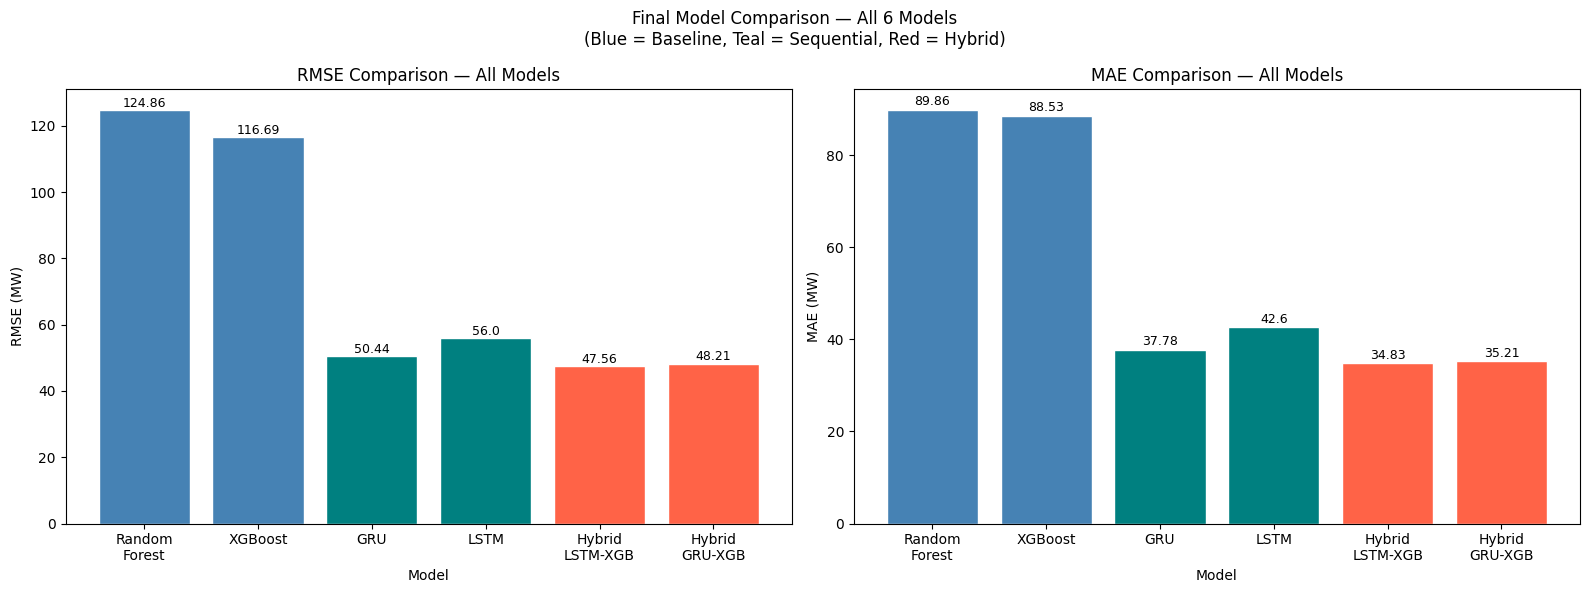

In [ ]:
# Build the final six-model RMSE/MAE comparison chart
models = ['Random\nForest', 'XGBoost', 'GRU', 'LSTM',
          'Hybrid\nLSTM-XGB', 'Hybrid\nGRU-XGB']

rmse_values = [
    get_rmse(rf_results),
    get_rmse(baseline),
    get_rmse(gru_preds),
    get_rmse(lstm_results),
    get_rmse(hybrid_results),
    get_rmse(results)
]

mae_values = [
    get_mae(rf_results),
    get_mae(baseline),
    get_mae(gru_preds),
    get_mae(lstm_results),
    get_mae(hybrid_results),
    get_mae(results)
]

colors = ['steelblue', 'steelblue', 'teal', 'teal', 'tomato', 'tomato']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(models, rmse_values, color=colors, edgecolor='white')
axes[0].set_title('RMSE Comparison — All Models')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('RMSE (MW)')
for i, v in enumerate(rmse_values):
    axes[0].text(i, v + 1, str(v), ha='center', fontsize=9)

axes[1].bar(models, mae_values, color=colors, edgecolor='white')
axes[1].set_title('MAE Comparison — All Models')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('MAE (MW)')
for i, v in enumerate(mae_values):
    axes[1].text(i, v + 1, str(v), ha='center', fontsize=9)

plt.suptitle('Final Model Comparison — All 6 Models\n(Blue = Baseline, Teal = Sequential, Red = Hybrid)', fontsize=12)
plt.tight_layout()
plt.savefig('/content/step5b_final_comparison.png', dpi=150)
plt.show()


In [ ]:
# Save the hybrid GRU-XGBoost predictions and model
results.to_csv('/content/hybrid_gru_predictions.csv')
hybrid_gru_model.save_model('/content/hybrid_gru_model.json')

print("Saved: hybrid_gru_predictions.csv")
print("Saved: hybrid_gru_model.json")
print("Step 5b complete")

Saved: hybrid_gru_predictions.csv
Saved: hybrid_gru_model.json
Step 5b complete
